<a href="https://colab.research.google.com/github/LatiefDataVisionary/DeepRice-Classifier-CNN/blob/main/EDA_Data_Lomba_Data_Analytics_Competition_(DAC)_Find_IT_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import os
import zipfile
from pathlib import Path

# Menghubungkan ke Google Drive
drive.mount('/content/drive')

# Mendefinisikan path sumber dan target
zip_path = '/content/drive/My Drive/Dataset/data-analytics-competition-dac-find-it-2026.zip'
extract_path = '/content/extracted_dataset'

# Memastikan file ada sebelum diproses
if os.path.exists(zip_path):
    print(f'✅ File ZIP ditemukan: {zip_path}')
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f'🚀 Ekstraksi berhasil ke: {extract_path}')
else:
    print(f'❌ Error: File tidak ditemukan di {zip_path}. Pastikan folder Dataset ada di Root My Drive.')

Mounted at /content/drive
✅ File ZIP ditemukan: /content/drive/My Drive/Dataset/data-analytics-competition-dac-find-it-2026.zip
🚀 Ekstraksi berhasil ke: /content/extracted_dataset


In [3]:
def get_size_format(b, factor=1024, suffix="B"):
    """Mengonversi bytes ke format yang mudah dibaca (KB, MB, GB, dll)"""
    for unit in ["", "K", "M", "G", "T", "P"]:
        if b < factor: return f"{b:.2f}{unit}{suffix}"
        b /= factor

def print_tree_structure(directory, indent=""):
    """Fungsi rekursif jenius untuk menampilkan silsilah file secara detail"""
    items = sorted(os.listdir(directory))
    for i, item in enumerate(items):
        path = os.path.join(directory, item)
        is_last = (i == len(items) - 1)

        # Simbol untuk struktur pohon
        connector = "└── " if is_last else "├── "

        if os.path.isdir(path):
            # Menghitung statistik folder
            num_files = 0
            folder_size = 0
            for r, d, files in os.walk(path):
                num_files += len(files)
                # Menghitung ukuran setiap file di dalam folder secara aman
                for f in files:
                    file_path = os.path.join(r, f)
                    if os.path.exists(file_path):
                        folder_size += os.path.getsize(file_path)

            print(f"{indent}{connector}📂 [1;34m{item}[0m | [1;32m{get_size_format(folder_size)}[0m | {num_files} files")

            # Rekursi ke dalam folder
            new_indent = indent + ("    " if is_last else "│   ")
            print_tree_structure(path, new_indent)
        else:
            # Menampilkan file (daun)
            file_size = os.path.getsize(path)
            print(f"{indent}{connector}📄 {item} ({get_size_format(file_size)})")

print("="*80)
print("📊 ANALISIS STRUKTUR DATASET: DATA ANALYTICS COMPETITION")
print("="*80)
if os.path.exists(extract_path):
    print(f"Root: {extract_path}")
    print_tree_structure(extract_path)
else:
    print("Data belum diekstrak.")
print("="*80)

📊 ANALISIS STRUKTUR DATASET: DATA ANALYTICS COMPETITION
Root: /content/extracted_dataset
├── 📄 samplesubmission.csv (3.95KB)
├── 📂 test | 285.02MB | 404 files
│   ├── 📄 test_001.jpg (339.53KB)
│   ├── 📄 test_002.jpg (144.17KB)
│   ├── 📄 test_003.jpg (525.88KB)
│   ├── 📄 test_004.jpg (360.19KB)
│   ├── 📄 test_005.jpg (421.75KB)
│   ├── 📄 test_006.jpg (49.51KB)
│   ├── 📄 test_007.jpg (478.36KB)
│   ├── 📄 test_008.jpg (102.23KB)
│   ├── 📄 test_009.jpg (806.14KB)
│   ├── 📄 test_010.jpg (254.25KB)
│   ├── 📄 test_011.jpg (1.52MB)
│   ├── 📄 test_012.jpg (110.23KB)
│   ├── 📄 test_013.jpg (219.84KB)
│   ├── 📄 test_014.jpg (198.57KB)
│   ├── 📄 test_015.jpg (40.30KB)
│   ├── 📄 test_016.jpg (169.09KB)
│   ├── 📄 test_017.jpg (71.57KB)
│   ├── 📄 test_018.jpg (397.73KB)
│   ├── 📄 test_019.jpg (287.70KB)
│   ├── 📄 test_020.jpeg (38.83KB)
│   ├── 📄 test_021.jpg (69.29KB)
│   ├── 📄 test_022.jpg (40.06KB)
│   ├── 📄 test_023.jpg (2.58MB)
│   ├── 📄 test_024.jpg (144.09KB)
│   ├── 📄 test_025.jpg (424.66KB)


In [4]:
import os
import pandas as pd
from pathlib import Path
from datetime import datetime

def get_formatted_size(size_bytes):
    if size_bytes == 0: return "0B"
    size_name = ("B", "KB", "MB", "GB", "TB")
    import math
    i = int(math.floor(math.log(size_bytes, 1024)))
    p = math.pow(1024, i)
    s = round(size_bytes / p, 2)
    return f"{s} {size_name[i]}"

def analyze_dataset(root_path):
    data_info = []
    extension_counts = {}
    total_size = 0
    total_files = 0

    for root, dirs, files in os.walk(root_path):
        folder_name = os.path.relpath(root, root_path)
        if folder_name == ".": folder_name = "Root"

        f_count = len(files)
        f_size = sum(os.path.getsize(os.path.join(root, f)) for f in files)

        total_files += f_count
        total_size += f_size

        for f in files:
            ext = Path(f).suffix.lower() or "No Extension"
            extension_counts[ext] = extension_counts.get(ext, 0) + 1

        data_info.append({
            "Komponen Struktur": f"┐ {folder_name}",
            "Jumlah File": f_count,
            "Ukuran Total": get_formatted_size(f_size),
            "Rata-rata Ukuran": get_formatted_size(f_size/f_count) if f_count > 0 else "0B",
            "Status": "✅ Terverifikasi"
        })

    # Membuat DataFrame untuk tampilan profesional
    df_structure = pd.DataFrame(data_info)

    print("="*100)
    print(f" Đ  DATASET EXECUTIVE SUMMARY REPORT - {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}  Đ ")
    print("="*100)
    print(f"Location: {root_path}")
    print(f"Total Keseluruhan File: {total_files}")
    print(f"Total Volume Data      : {get_formatted_size(total_size)}")
    print("-"*100)

    print("\n[1] TABEL ANALISIS STRUKTUR DIREKTORI")
    display(df_structure.style.set_properties(**{'text-align': 'left', 'border': '1px solid black'})
            .set_table_styles([{'selector': 'th', 'props': [('background-color', '#1f77b4'), ('color', 'white'), ('font-weight', 'bold')]}]))

    print("\n[2] DISTRIBUSI FORMAT FILE (EXTENSIONS)")
    df_ext = pd.DataFrame(list(extension_counts.items()), columns=['Format/Ekstensi', 'Jumlah'])
    df_ext['Persentase'] = df_ext['Jumlah'].apply(lambda x: f"{(x/total_files)*100:.2f}%")
    display(df_ext.sort_values(by='Jumlah', ascending=False).style.hide(axis='index'))

    print("\n" + "="*100)
    print("LAPORAN SELESAI: Data siap untuk diproses ke tahap Exploratory Data Analysis (EDA).")
    print("="*100)

# Menjalankan fungsi analisis pada path hasil ekstraksi
analyze_dataset('/content/extracted_dataset')

 Đ  DATASET EXECUTIVE SUMMARY REPORT - 2026-03-29 08:16:03  Đ 
Location: /content/extracted_dataset
Total Keseluruhan File: 2057
Total Volume Data      : 1.18 GB
----------------------------------------------------------------------------------------------------

[1] TABEL ANALISIS STRUKTUR DIREKTORI


,Komponen Struktur,Jumlah File,Ukuran Total,Rata-rata Ukuran,Status
0,┐ Root,1,3.95 KB,3.95 KB,✅ Terverifikasi
1,┐ train,0,0B,0B,✅ Terverifikasi
2,┐ train/fake_screen,229,91.26 MB,408.09 KB,✅ Terverifikasi
3,┐ train/fake_mask,278,213.48 MB,786.34 KB,✅ Terverifikasi
4,┐ train/realperson,465,439.58 MB,968.01 KB,✅ Terverifikasi
5,┐ train/fake_unknown,338,39.09 MB,118.43 KB,✅ Terverifikasi
6,┐ train/fake_mannequin,224,36.4 MB,166.38 KB,✅ Terverifikasi
7,┐ train/fake_printed,118,99.44 MB,862.95 KB,✅ Terverifikasi
8,┐ test,404,285.02 MB,722.43 KB,✅ Terverifikasi



[2] DISTRIBUSI FORMAT FILE (EXTENSIONS)


Format/Ekstensi,Jumlah,Persentase
.jpg,1628,79.14%
.jpeg,424,20.61%
.png,4,0.19%
.csv,1,0.05%



LAPORAN SELESAI: Data siap untuk diproses ke tahap Exploratory Data Analysis (EDA).


/tmp/ipykernel_9224/2076465209.py:32: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


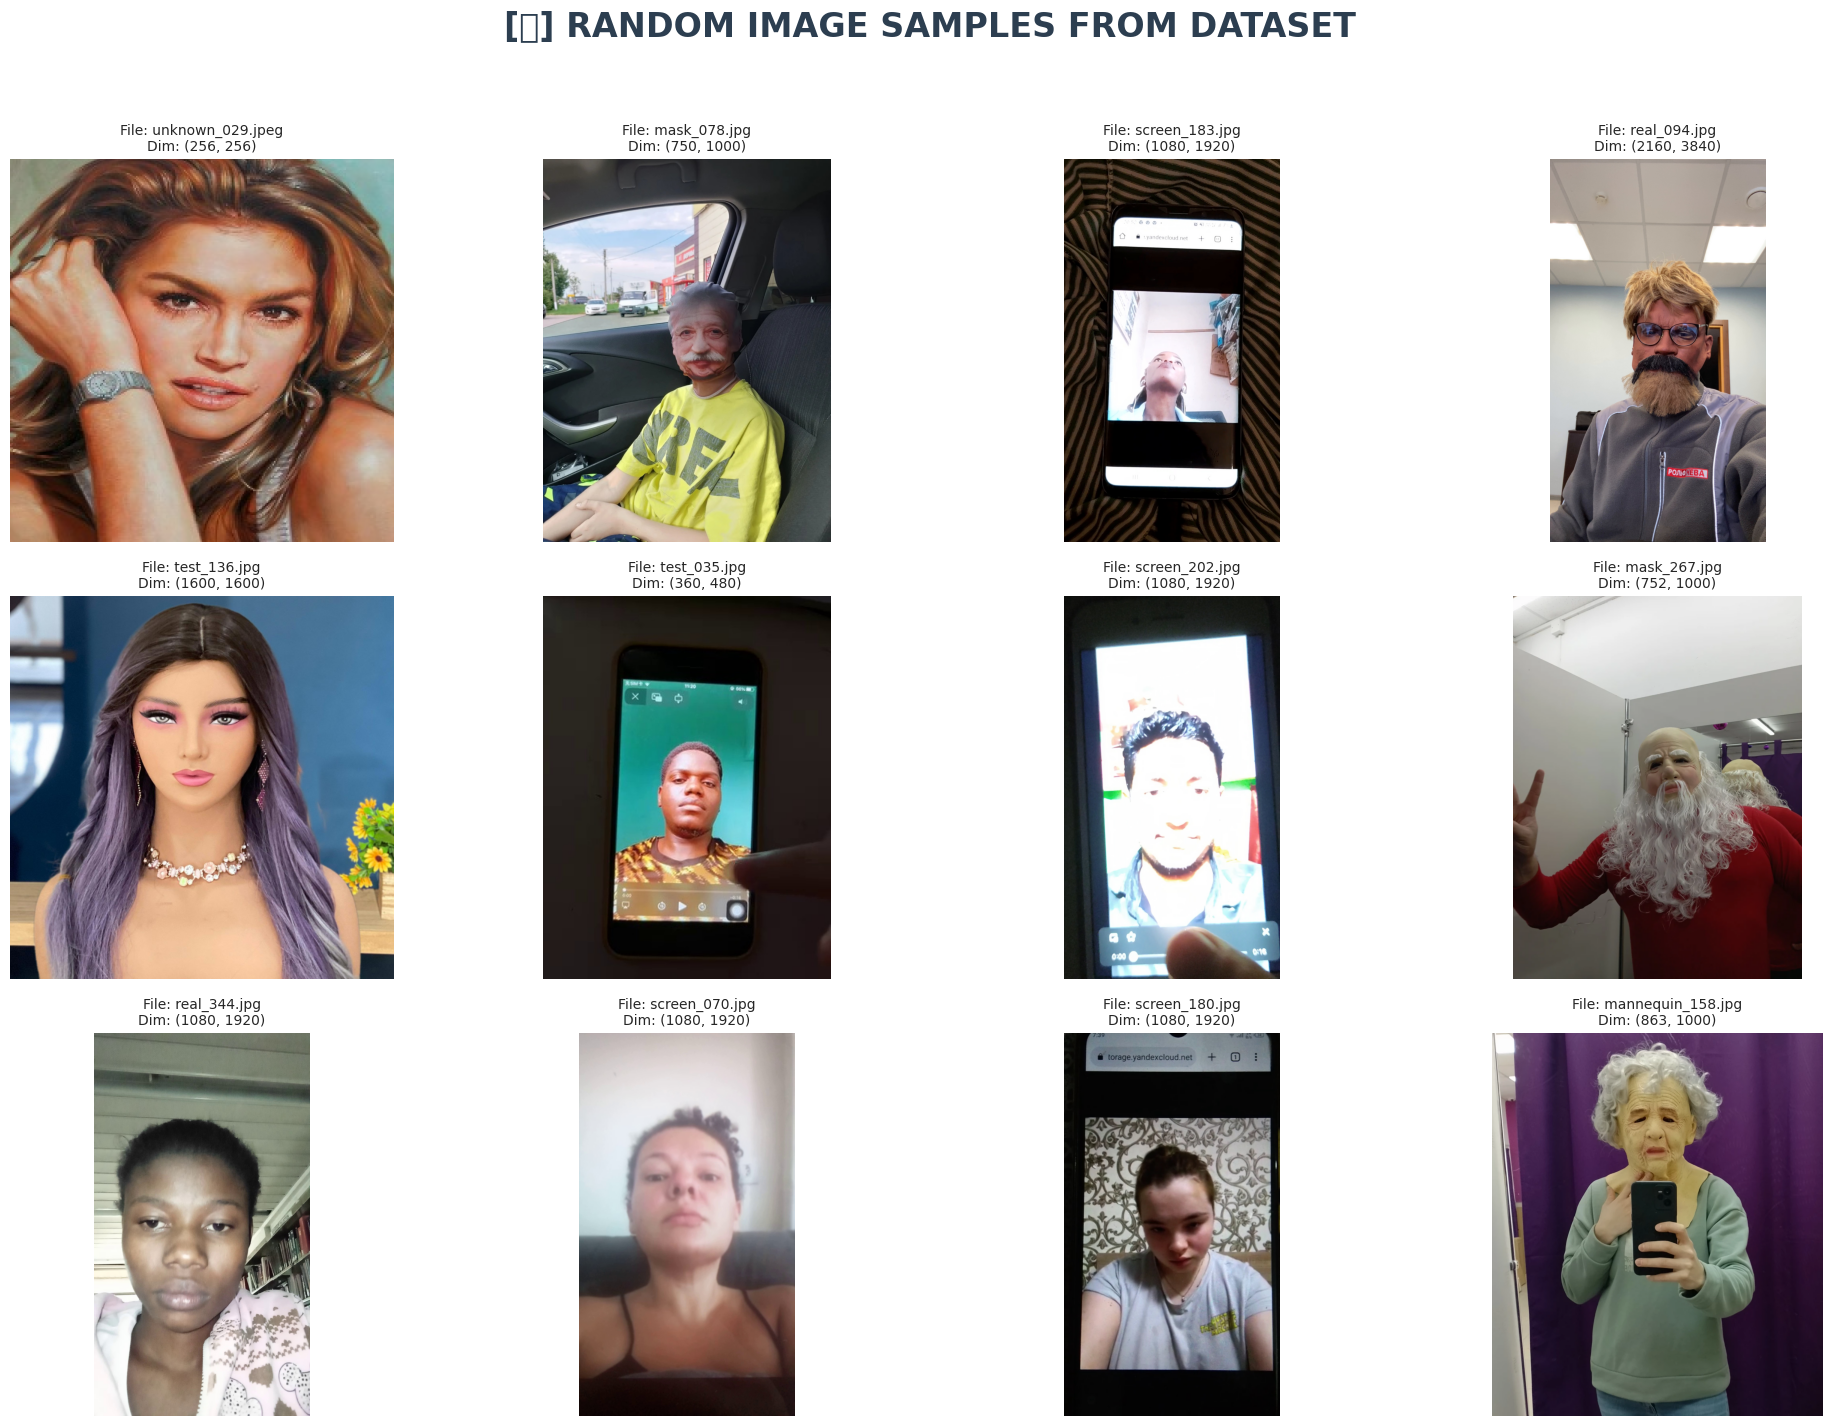

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random
from PIL import Image
import numpy as np

# Konfigurasi Estetika Visual
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (15, 10)

def display_sample_images(base_path, num_samples=12):
    """Menampilkan galeri sampel gambar secara profesional"""
    all_images = []
    for root, dirs, files in os.walk(base_path):
        for f in files:
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                all_images.append(os.path.join(root, f))

    samples = random.sample(all_images, min(num_samples, len(all_images)))

    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    fig.suptitle('[✨] RANDOM IMAGE SAMPLES FROM DATASET', fontsize=24, fontweight='bold', color='#2c3e50')

    for i, img_path in enumerate(samples):
        ax = axes[i//4, i%4]
        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(f"File: {os.path.basename(img_path)}\nDim: {img.size}", fontsize=10)
        ax.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Eksekusi Visualisasi
display_sample_images(extract_path)

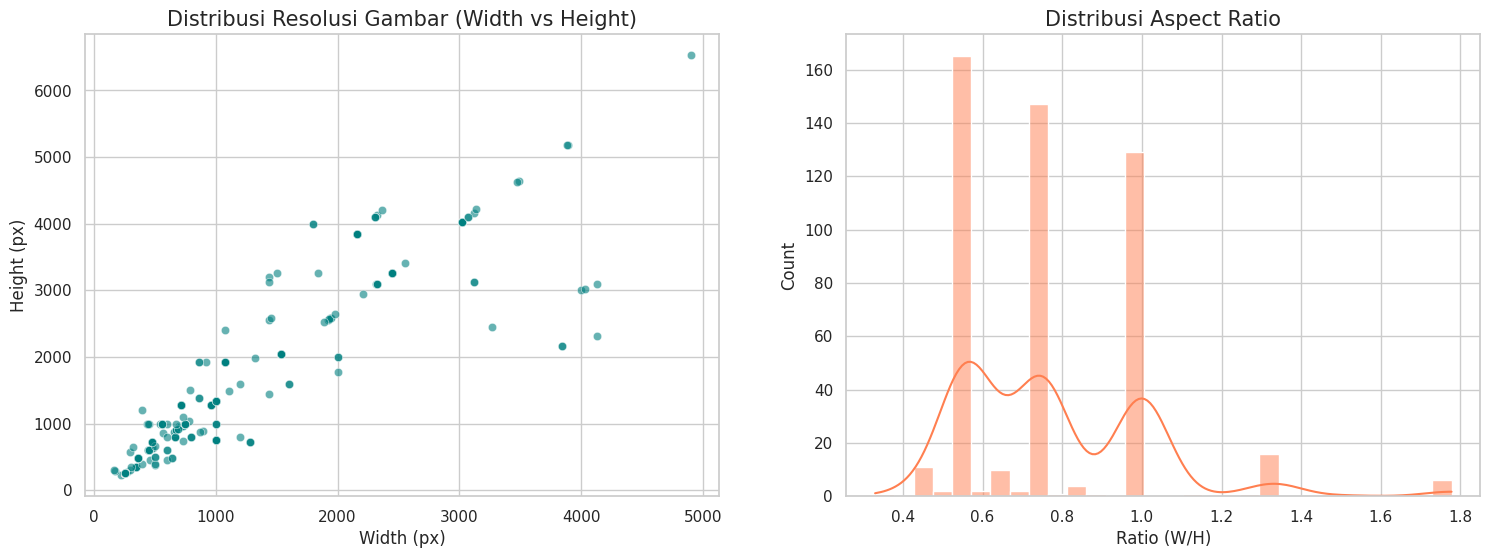

Average Resolution: 1101x1600 px
Median Aspect Ratio: 0.75


In [6]:
def analyze_image_properties(base_path, limit=500):
    """Menganalisis resolusi dan aspect ratio dari sampel data gambar"""
    widths, heights, ratios = [], [], []
    all_files = []
    for root, dirs, files in os.walk(base_path):
        for f in files:
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                all_files.append(os.path.join(root, f))

    # Sampling limit untuk kecepatan eksekusi
    sample_files = random.sample(all_files, min(limit, len(all_files)))

    for img_path in sample_files:
        with Image.open(img_path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
            ratios.append(w/h)

    # Visualisasi Distribusi
    fig, ax = plt.subplots(1, 2, figsize=(18, 6))

    sns.scatterplot(x=widths, y=heights, alpha=0.6, ax=ax[0], color='teal')
    ax[0].set_title('Distribusi Resolusi Gambar (Width vs Height)', fontsize=15)
    ax[0].set_xlabel('Width (px)')
    ax[0].set_ylabel('Height (px)')

    sns.histplot(ratios, bins=30, kde=True, ax=ax[1], color='coral')
    ax[1].set_title('Distribusi Aspect Ratio', fontsize=15)
    ax[1].set_xlabel('Ratio (W/H)')

    plt.show()

    print(f"Average Resolution: {np.mean(widths):.0f}x{np.mean(heights):.0f} px")
    print(f"Median Aspect Ratio: {np.median(ratios):.2f}")

analyze_image_properties(extract_path)

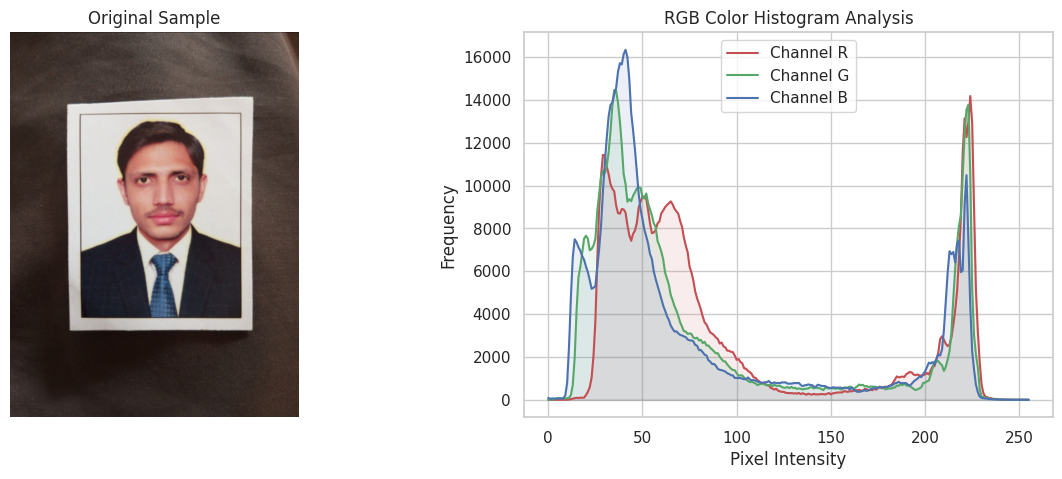

In [7]:
def plot_color_distribution(image_path):
    """Menganalisis distribusi warna pada satu sampel gambar representatif"""
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    colors = ('r', 'g', 'b')
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original Sample")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    for i, col in enumerate(colors):
        hist = cv2.calcHist([img], [i], None, [256], [0, 256])
        plt.plot(hist, color=col, label=f'Channel {col.upper()}')
        plt.fill_between(range(256), hist.flatten(), alpha=0.1, color=col)

    plt.title("RGB Color Histogram Analysis")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

# Ambil satu gambar random untuk dianalisis histogramnya
random_img = random.choice([os.path.join(dp, f) for dp, dn, filenames in os.walk(extract_path) for f in filenames if f.endswith('.jpg')])
plot_color_distribution(random_img)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 4098 (\N{MYANMAR LETTER GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


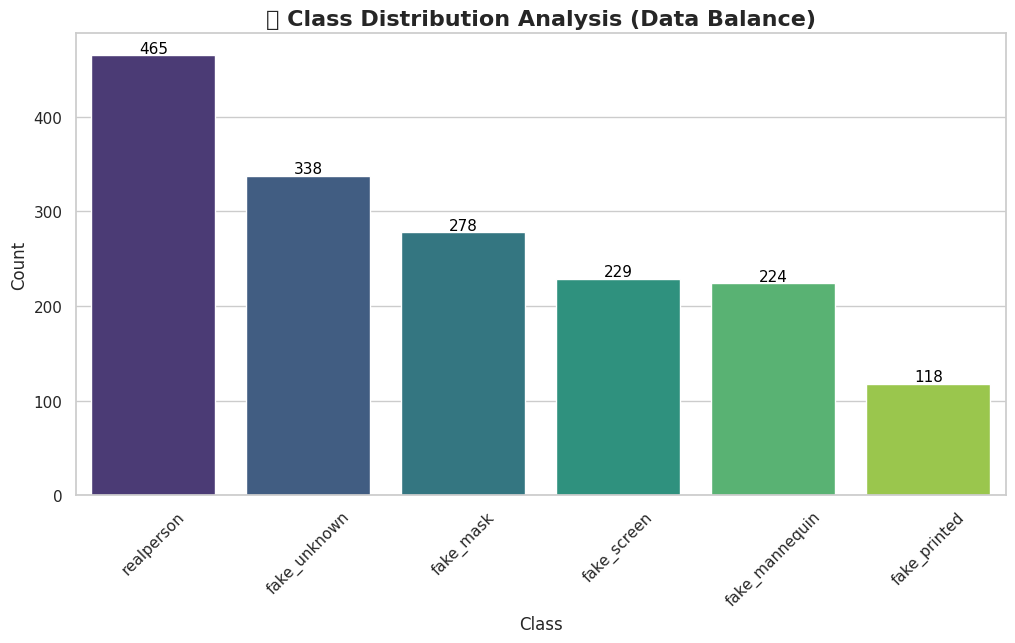

Total Data Training: 1652 file


Class,Count,Persentase Kontribusi
realperson,465,28.15%
fake_unknown,338,20.46%
fake_mask,278,16.83%
fake_screen,229,13.86%
fake_mannequin,224,13.56%
fake_printed,118,7.14%


In [11]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_class_distribution(base_path):
    # Mencari subfolder di dalam train (asumsi struktur folder adalah label)
    train_path = os.path.join(base_path, 'train')
    if not os.path.exists(train_path):
        # Jika tidak ada folder train, scan folder root untuk sub-direktori
        train_path = base_path

    class_counts = {}
    for item in os.listdir(train_path):
        item_path = os.path.join(train_path, item)
        if os.path.isdir(item_path):
            count = len([f for f in os.listdir(item_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            class_counts[item] = count

    if not class_counts:
        print("Tidak ditemukan sub-direktori kelas di path tersebut.")
        return

    # Membuat DataFrame
    df_classes = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Count']).sort_values('Count', ascending=False)

    # Menambahkan kolom Persentase Kontribusi
    total_train_files = df_classes['Count'].sum()
    df_classes['Persentase Kontribusi'] = df_classes['Count'].apply(lambda x: f"{(x/total_train_files)*100:.2f}%")

    # Visualisasi
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=df_classes, x='Class', y='Count', palette='viridis', hue='Class', legend=False)
    plt.title('ဂ Class Distribution Analysis (Data Balance)', fontsize=16, fontweight='bold')
    plt.xticks(rotation=45)

    # Menambahkan label angka di atas bar
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                    textcoords='offset points')

    plt.show()

    # Menampilkan tabel dengan gaya profesional
    print(f"Total Data Training: {total_train_files} file")
    display(df_classes.style.hide(axis='index').set_properties(**{'text-align': 'center', 'border': '1px solid gray'}))

plot_class_distribution(extract_path)

Analyzing Image Quality: 100%|██████████| 300/300 [00:21<00:00, 14.18it/s]


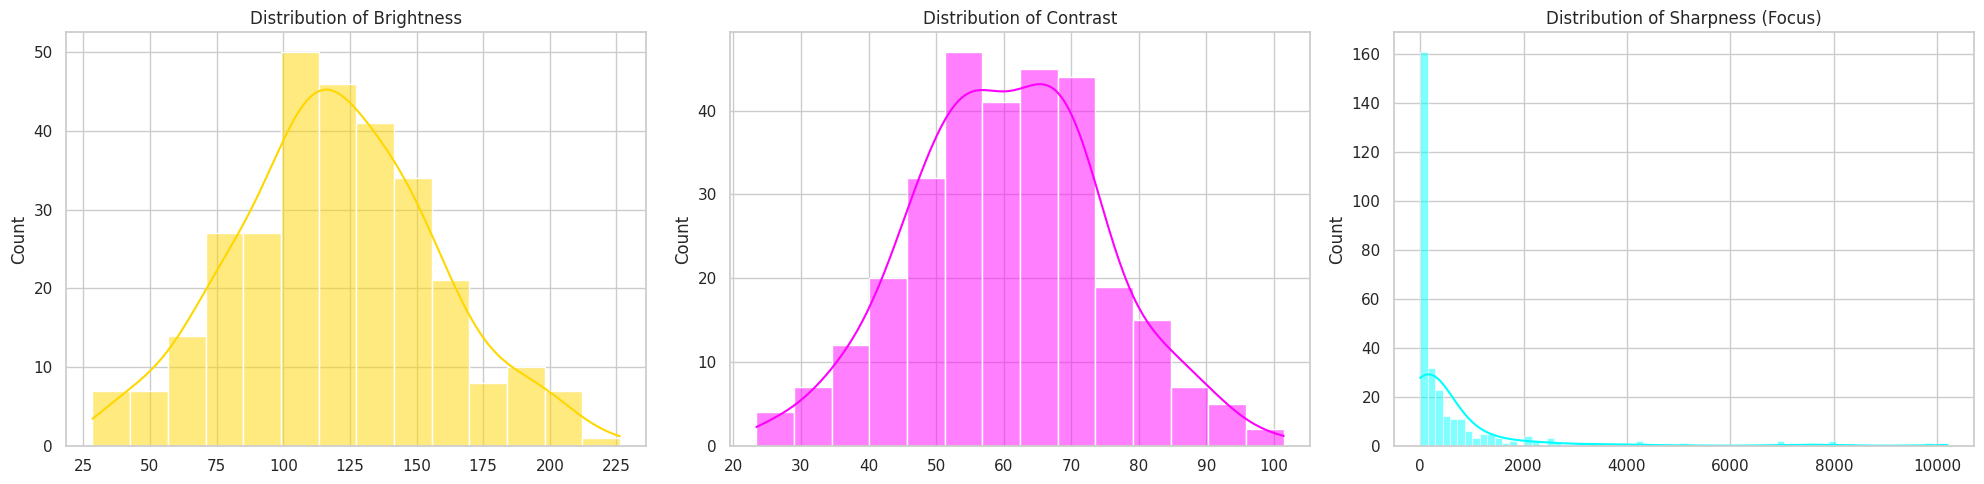

In [9]:
import cv2
import numpy as np
from tqdm import tqdm

def analyze_image_quality(base_path, sample_size=300):
    brightness_list = []
    contrast_list = []
    sharpness_list = []

    all_files = []
    for root, dirs, files in os.walk(base_path):
        for f in files:
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                all_files.append(os.path.join(root, f))

    samples = random.sample(all_files, min(sample_size, len(all_files)))

    for img_p in tqdm(samples, desc="Analyzing Image Quality"):
        img = cv2.imread(img_p)
        if img is None: continue
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Brightness (Mean Pixel Intensity)
        brightness_list.append(np.mean(gray))
        # Contrast (Standard Deviation)
        contrast_list.append(np.std(gray))
        # Sharpness (Laplacian Variance)
        sharpness_list.append(cv2.Laplacian(gray, cv2.CV_64F).var())

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    sns.histplot(brightness_list, kde=True, ax=axes[0], color='gold')
    axes[0].set_title('Distribution of Brightness')

    sns.histplot(contrast_list, kde=True, ax=axes[1], color='magenta')
    axes[1].set_title('Distribution of Contrast')

    sns.histplot(sharpness_list, kde=True, ax=axes[2], color='cyan')
    axes[2].set_title('Distribution of Sharpness (Focus)')

    plt.tight_layout()
    plt.show()

analyze_image_quality(extract_path)

/tmp/ipykernel_9224/1988912977.py:55: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.92])
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


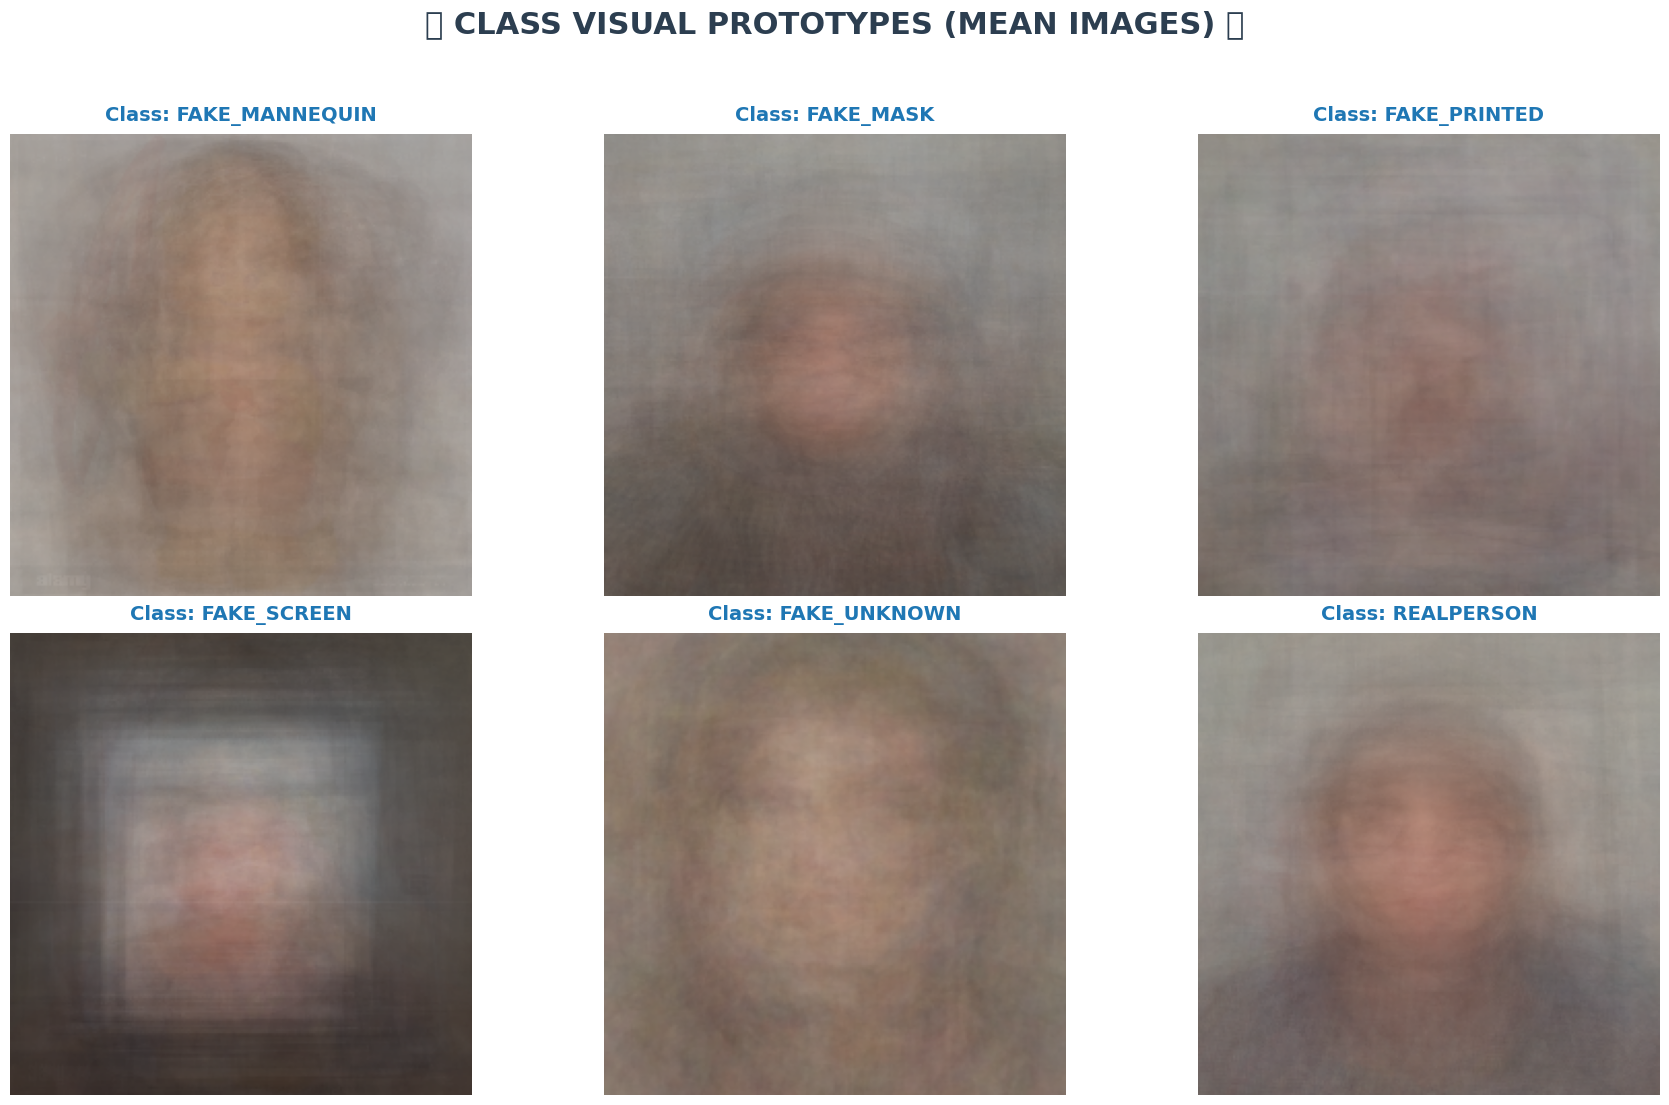

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def compute_mean_image(folder_path, target_size=(224, 224)):
    """Menghitung rata-rata gambar untuk satu kelas dengan resolusi lebih tinggi"""
    images = []
    valid_extensions = ('.jpg', '.jpeg', '.png')
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(valid_extensions)][:100] # Sampel lebih banyak untuk akurasi

    for f in files:
        img = cv2.imread(os.path.join(folder_path, f))
        if img is not None:
            img = cv2.resize(img, target_size)
            images.append(img.astype(np.float32))

    if not images: return None
    # Menghitung mean secara presisi dan konversi kembali ke uint8
    mean_img = np.mean(images, axis=0).astype(np.uint8)
    return cv2.cvtColor(mean_img, cv2.COLOR_BGR2RGB)

train_dir = os.path.join(extract_path, 'train')
if os.path.exists(train_dir):
    subdirs = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])

    # Konfigurasi Grid Dinamis
    n_classes = len(subdirs)
    cols = 3
    rows = (n_classes + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(18, 6 * rows))
    fig.suptitle('✨ CLASS VISUAL PROTOTYPES (MEAN IMAGES) ✨', fontsize=22, fontweight='bold', y=0.95, color='#2c3e50')
    axes = axes.flatten()

    for i, subdir in enumerate(subdirs):
        path = os.path.join(train_dir, subdir)
        mean_img = compute_mean_image(path)

        if mean_img is not None:
            axes[i].imshow(mean_img)
            # Styling Subplot
            axes[i].set_title(f"Class: {subdir.upper()}", fontsize=14, fontweight='bold', pad=10, color='#1f77b4')
            # Menambahkan border pada gambar
            for spine in axes[i].spines.values():
                spine.set_edgecolor('#bdc3c7')
                spine.set_linewidth(2)

        axes[i].axis('off')

    # Menghilangkan axes kosong jika jumlah kelas tidak genap dengan grid
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.92])
    plt.show()
else:
    print("❌ Direktori 'train' tidak ditemukan untuk analisis Mean Image.")

In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import cv2
import numpy as np

def perform_pca_analysis(base_path, sample_per_class=40):
    train_path = os.path.join(base_path, 'train')
    data, labels = [], []

    subdirs = sorted([d for d in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, d))])

    for label in subdirs:
        path = os.path.join(train_path, label)
        files = [f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:sample_per_class]
        for f in files:
            img = cv2.imread(os.path.join(path, f), 0)
            img = cv2.resize(img, (64, 64)).flatten()
            data.append(img)
            labels.append(label)

    data = np.array(data)
    scaled_data = StandardScaler().fit_transform(data)

    pca = PCA(n_components=2)
    pca_res = pca.fit_transform(scaled_data)

    plt.figure(figsize=(12, 8))
    sns.scatterplot(x=pca_res[:,0], y=pca_res[:,1], hue=labels, palette='tab10', s=100, alpha=0.7)
    plt.title('✨ 2D PCA PROJECTION OF IMAGE FEATURES ✨', fontsize=16, fontweight='bold')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

In [14]:
def analyze_edge_density(base_path, sample_size=200):
    edge_densities = []
    labels = []
    train_path = os.path.join(base_path, 'train')

    subdirs = sorted([d for d in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, d))])

    for label in subdirs:
        path = os.path.join(train_path, label)
        files = [f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:sample_size//len(subdirs)]
        for f in files:
            img = cv2.imread(os.path.join(path, f), 0)
            edges = cv2.Canny(img, 100, 200)
            density = np.sum(edges > 0) / (img.shape[0] * img.shape[1])
            edge_densities.append(density)
            labels.append(label)

    df_edges = pd.DataFrame({'Class': labels, 'Edge Density': edge_densities})

    plt.figure(figsize=(14, 6))
    sns.boxplot(data=df_edges, x='Class', y='Edge Density', palette='coolwarm')
    plt.title('ပ Edge Density Distribution by Class', fontsize=16, fontweight='bold')
    plt.xticks(rotation=45)
    plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


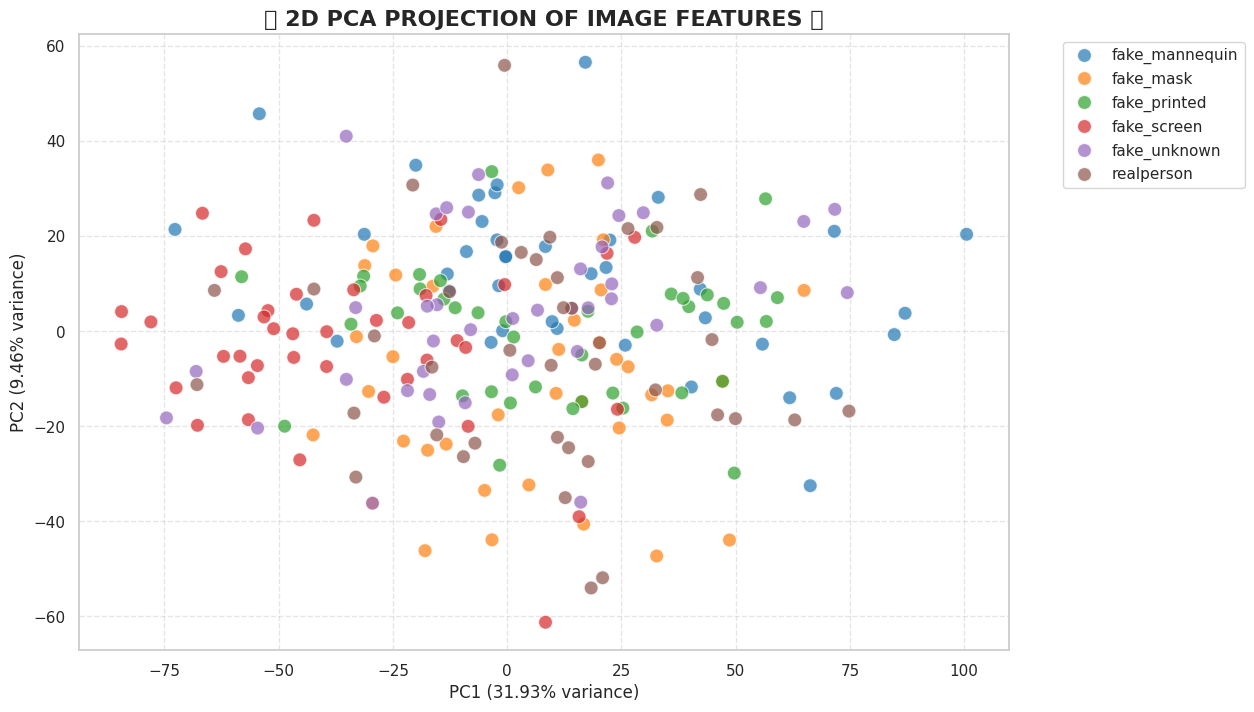

/tmp/ipykernel_9224/699832749.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_edges, x='Class', y='Edge Density', palette='coolwarm')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 4117 (\N{MYANMAR LETTER PA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


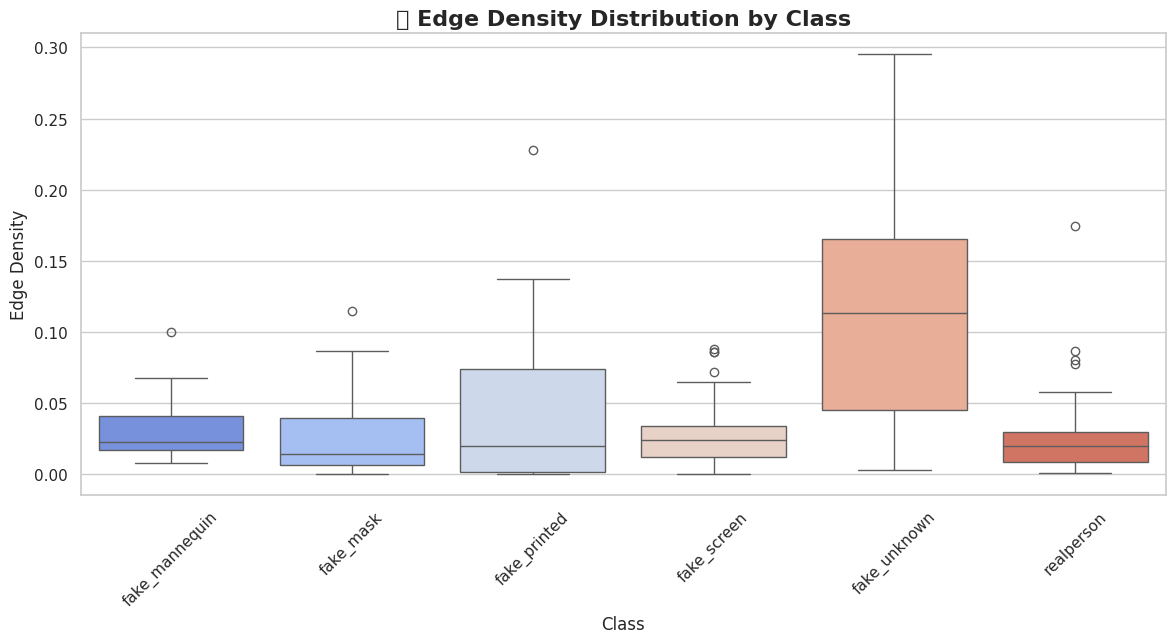

In [15]:
perform_pca_analysis(extract_path)
analyze_edge_density(extract_path)